# Chapter 23. 작은 BERT 분류 — 한국어 NSMC 이진 (일반 도메인 사전학습 → 다른 도메인 fine-tune)

**목표**: Phase 3 의 마지막 챕터. Ch 22 에서 *작은 한국어 BERT 를 일반 도메인 (한국어 Wikipedia) 으로 직접 MLM 사전학습* 했다면, 이번엔 그 위에 **분류 헤드를 얹어 *완전히 다른 도메인 (NSMC 영화 리뷰)* 이진 분류로 fine-tune** 합니다. Ch 15 (`klue/bert-base`, 약 110M params, 약 8.4B 토큰 대규모 한국어 사전학습) 와 같은 NSMC 분류 셋업에 *우리가 만든 작은 BERT* (약 10M params, 한국어 위키 2K paragraphs × 3 epoch MLM) 를 붙여 두 결과를 나란히 비교 — 둘 다 *일반 한국어 사전학습 → NSMC transfer* 라 비교가 *fair*, *사전학습 규모* 차이만 측정됩니다.

본 챕터의 강점: *위키 사전학습 → NSMC 분류 transfer* 가 **진짜 transfer**. 사전학습이 *task 도메인 (영화 리뷰) 자체* 를 본 적이 없는 일반 위키 본문으로 진행되어, *일반 표상 학습 → 다른 도메인 fine-tune* 의 정직한 메시지가 나옵니다. **두 데이터셋이 노트북 안에 공존** — MLM 용 한국어 Wikipedia (2K paragraphs × 3 epoch) + 분류용 NSMC (5K/1K).

self-contained 노트북: Ch 22 의 MLM 학습을 짧게 재현 → 같은 본체로 분류 fine-tune → Ch 15 결과와 2-way 비교. **random init baseline 비교 + negative transfer 분석** 은 부록 노트북 [`appendix_random_baseline.ipynb`](./appendix_random_baseline.ipynb) 으로 분리.

**환경**: Google Colab **T4 GPU 필수**.

**예상 소요 시간**: 약 20-23분 (한국어 위키 다운로드·필터링 약 2분 + MLM 3 epoch 약 8-10분 + 분류 fine-tune 2 epoch 약 8-10분 + 평가 약 2분)

---

## 학습 흐름

1. 🚀 **분류 데이터**: NSMC 이진 (e9t/nsmc, GitHub raw TSV, Ch 15 와 같은 5K/1K split, seed 42)
2. 🔤 **토크나이저**: `klue/bert-base` (Ch 22 와 동일)
3. 📥 **MLM 사전학습 데이터**: `wikimedia/wikipedia` `20231101.ko` paragraphs 5K (일반 도메인 — *분류용 NSMC 와 별도*)
4. 🏗️ **MLM 사전학습 재현 (Ch 22 압축본)**: 같은 작은 BertConfig 로 1 epoch 만 짧게
5. 🔀 **헤드 교체**: `BertForMaskedLM` → `BertForSequenceClassification(num_labels=2)`. 본체는 그대로, MLM head 떼고 분류 head 부착
6. 🚀 **분류 fine-tune**: Trainer fp16, 2 epoch
7. 🔬 **평가**: accuracy / precision / recall / F1 / AUC (Ch 15 / Ch 21 과 같은 5종) + confusion matrix
8. 🆚 **Ch 15 vs Ch 23 ours** 2-way 비교 — 정확도, 모델 크기, 사전학습 토큰량
9. 📒 **부록**: random init baseline + negative transfer 분석 → [`appendix_random_baseline.ipynb`](./appendix_random_baseline.ipynb)

---

> 📒 **사전 학습 자료**: Ch 22 (한국어 작은 BERT scratch MLM, 한국어 Wikipedia), Ch 15 (`klue/bert-base` 한국어 사전학습 + NSMC 이진 분류), Ch 21 (영어 작은 BERT 분류 — 본 챕터의 영어 대칭본). Ch 23 은 세 챕터를 *합쳐서* — Ch 22 의 한국어 일반 도메인 사전학습 흐름 그대로 + Ch 15 의 한국어 분류 fine-tune 평가 그대로 + Ch 21 의 transfer 메시지를 한국어 환경에서 재확인. **Phase 3 의 마지막 챕터** — Phase 4 (Ch 24, GPT scratch) 부터는 *decoder-only* 와 *SFT 의미의 파인튜닝* 으로 흐름이 바뀝니다.

## 📊 변화추적표

| Ch | 모델 | 토크나이저 | 데이터 | Output Head | Activation | Loss |
|---|---|---|---|---|---|---|
| 15 | `klue/bert-base` 파인튜닝 (약 110M) | WordPiece (한국어, 사전학습) | NSMC (네이버 영화 리뷰, 이진) | `Linear(H, 2)` | softmax | `CrossEntropyLoss` |
| 20 | 작은 BERT (직접, scratch) | `bert-base-uncased` 토크나이저 (가져옴) | Wikitext-103 paragraphs (일반 도메인) | MLM head | softmax (MLM) | `CrossEntropyLoss` (masked token) |
| 21 | Ch 20 사전학습 BERT + 분류 헤드 (약 10M) | (Ch 20과 동일) | Yelp 이진화 (다른 도메인 transfer) | `Linear(H, 2)` | softmax | `CrossEntropyLoss` |
| 22 | 작은 BERT (직접, scratch) — 한국어 | `klue/bert-base` 토크나이저 (가져옴) | 한국어 Wikipedia paragraphs (일반 도메인) | MLM head | softmax (MLM) | `CrossEntropyLoss` (masked token) |
| **23 ← 여기** | **Ch 22 사전학습 BERT + 분류 헤드 (약 10M)** | **(Ch 22와 동일)** | **NSMC 이진 (다른 도메인 transfer)** | **`Linear(H, 2)`** | **softmax** | **`CrossEntropyLoss`** |
| 24 (다음, Phase 4) | GPT-2 (직접, scratch) | BPE 토크나이저 (직접 학습) | TinyStories 영어 동화 | LM head | softmax (next-token) | `CrossEntropyLoss` (causal LM) |

전체 챕터 표는 [루트 README.md](https://github.com/yoon-gu/neuqes-101#챕터별-변화추적표)를 참고하세요.

**Phase 3 안에서의 위치** — Ch 19 (토크나이저 학습) → Ch 20 (영어 모델 사전학습) → Ch 21 (영어 분류) → Ch 22 (한국어 모델 사전학습) → **Ch 23 (한국어 분류, Phase 3 종료)**. Ch 22 → Ch 23 흐름이 Ch 20 → Ch 21 흐름의 *한국어 대칭본*. 본문의 클라이맥스는 *2-way 비교* — Ch 15 의 대규모 사전학습 모델과 본 챕터의 작은 자체 사전학습 모델의 격차로 *사전학습 규모의 가치* 를 정량 측정. 사전학습 자체의 *순* 효과 (random init baseline 대비) 와 *한국어 환경 특유의 negative transfer 가능성* 은 부록에서 다룹니다.

## 🔄 변경점 (Diff from Ch 22)

| 축 | Ch 22 (한국어 MLM scratch) | Ch 23 (한국어 분류 fine-tune) |
|---|---|---|
| **이 챕터의 task** | MLM 사전학습 (masked token 예측) | **이진 분류 (NSMC 긍정/부정)** ← *task 축 변화* |
| 모델 클래스 | `BertForMaskedLM` | **`BertForSequenceClassification(num_labels=2)`** |
| 본체 (embedding + encoder) | random init → 한국어 위키 MLM 학습 | **Ch 22 사전학습 본체 그대로 이어받음** |
| 출력 헤드 | MLM head (vocab 약 32,000 차원) | **분류 head (`Linear(256, 2)`)** ← 새 random init |
| 토크나이저 | `klue/bert-base` (vocab 약 32,000) | (그대로) |
| **데이터** | **한국어 Wikipedia paragraphs (일반 도메인, 라벨 없음)** | **NSMC 영화 리뷰 (다른 도메인, 라벨 사용)** ← *사전학습과 fine-tune 도메인이 다름* |
| Loss | `CrossEntropyLoss` (vocab 약 32,000 logits) | **`CrossEntropyLoss` (2 logits)** ← K 만 큰 변화 |
| 학습률 | 5e-4 (scratch MLM) | **2e-5** (fine-tune 표준) |

> **변경점 한 가지 원칙** — Phase 3 안에서 *task 축* 이 변합니다 (MLM → 분류). 데이터 *도메인* 도 같이 변합니다 (위키 → NSMC) — 이게 *진짜 transfer 의 본질*. 모델 본체·토크나이저는 그대로, 헤드와 라벨 형식·데이터 도메인이 바뀝니다. 이게 *사전학습-fine-tune 패러다임* 의 핵심: 본체는 한 번 학습한 *일반 표상* 을 재사용, downstream task 도메인마다 *작은 헤드 + 작은 학습률* 로 적응.

### 두 데이터셋이 노트북 안에 공존

본 챕터의 특수성 — 한 노트북에 두 데이터셋이 함께 들어갑니다.

| 단계 | 데이터셋 | 용도 |
|---|---|---|
| 3 §MLM 사전학습 | `wikimedia/wikipedia`, `20231101.ko` 2K paragraphs × 3 epoch | self-supervised MLM (라벨 없음, 일반 위키 본문) |
| 4-5 §분류 fine-tune | NSMC (e9t/nsmc GitHub raw TSV) 5K/1K | supervised 이진 분류 (긍정/부정 라벨) |

같은 토크나이저 (`klue/bert-base`) 가 두 데이터셋의 모든 텍스트를 처리. 본체가 *일반 위키 어휘* 로 사전학습된 표상이 *영화 리뷰 비격식 구어체 토큰* 에 얼마나 잘 전이되는가가 본 챕터의 측정 대상.

### Ch 15 (klue/bert-base) 와의 비교가 본 챕터의 메인 메시지 — 이제 *fair*

| 차원 | Ch 15 (klue/bert-base) | Ch 23 (이 챕터) | 비고 |
|---|---|---|---|
| 본체 파라미터 | 약 110M | **약 10M** | Ch 23 은 1/11 작음 |
| 사전학습 코퍼스 | 한국어 위키 + 모두의 말뭉치 + 뉴스 + 댓글 (약 8.4B 토큰, 일반 도메인) | **한국어 Wikipedia paragraphs 5K (약 50만-80만 토큰, 일반 도메인)** | 약 10,000배 격차, **둘 다 일반 한국어 코퍼스** |
| 사전학습 시간 | TPU 수일 | **T4 약 8-10분** | |
| Fine-tune 도메인 | NSMC 이진 (사전학습과 다른 도메인) | NSMC 이진 (사전학습과 다른 도메인) | **둘 다 일반 한국어 → NSMC transfer 라 fair** |
| 분류 fine-tune 셋업 | Ch 15 = 이번 챕터 동일 (같은 데이터, 같은 hyperparams) | | 변하는 건 *본체 출발점* 뿐 |
| 기대 accuracy | 약 85-88% | **약 65-75% 예상** | 비교는 실측치로 확인 |

비교가 *공정* 한 이유 — Ch 15 도 본 챕터도 둘 다 *일반 도메인 한국어 사전학습 → NSMC 분류 transfer* 의 같은 패턴. *사전학습 규모* (약 10,000배) 와 *모델 크기* (11배) 만 차이. 만약 Ch 23 이 NSMC text 로 사전학습했다면 비교가 unfair 했을 것 — domain-adaptive pretraining 우위 때문.

### Ch 21 (영어) → Ch 23 (한국어) 대칭

| 항목 | Ch 21 (영어) | Ch 23 (한국어, 이번 챕터) |
|---|---|---|
| 사전학습 코퍼스 (일반 도메인) | Wikitext-103 paragraphs 5K | 한국어 Wikipedia paragraphs 5K |
| 분류 데이터 (다른 도메인) | Yelp polarity 5K/1K | NSMC 5K/1K |
| 비교 대상 (대규모 사전학습) | Ch 10 (DistilBERT, 약 66M, 약 33억 토큰) | Ch 15 (`klue/bert-base`, 약 110M, 약 8.4B 토큰) |
| 토크나이저 | `bert-base-uncased` | `klue/bert-base` |
| 메시지 | *일반 위키 사전학습 → 영화 리뷰 transfer* | *일반 위키 사전학습 → 영화 리뷰 transfer* |

같은 결을 한국어 환경에서 재확인 — Phase 3 의 마지막 검증.

## 📐 Loss 함수의 변화 — MLM CE (vocab 약 32,000) → 분류 CE (K=2)

Ch 22 의 MLM 도 본질은 *vocab 위에서의 다중 분류* 였습니다. 다만 K = vocab_size 약 32,000 이라 어려운 task. 이번 챕터는 K = 2 의 *훨씬 쉬운* 분류 task.

### 수식

분류 task 의 CE 는 Ch 15 / Ch 21 과 같습니다 (K=2):

$$L_{\text{cls}} = -\frac{1}{N}\sum_{i=1}^{N} \log \hat p_{i, y_i}$$

- $\hat p_{i, k} = \mathrm{softmax}(z_i)_k$ — K=2 차원 softmax
- $y_i \in \{0, 1\}$ — 정수 라벨 (NSMC: 0=negative, 1=positive)

### 두 CE 비교 (random baseline)

| task | K | random baseline loss $\log K$ | 학습 어려움 |
|---|---|---|---|
| MLM (Ch 22) | 약 32,000 | **10.37** | 매우 어려움 — 가려진 토큰 자리에 *vocab 전체 후보* 중 정답을 |
| 분류 (Ch 23) | 2 | **0.693** | 상대적으로 쉬움 — 긍정/부정 둘 중 하나 |

학습 첫 step 의 loss 가 약 0.693 부근이면 모델이 *균등 추측* 단계. fine-tune 첫 step 에서 분류 헤드만 새로 init 됐으므로 *이 정도* 가 정상.

### 사전학습 효과가 *loss 곡선* 에 어떻게 드러나나

| 셋업 | 학습 첫 step loss | 학습 종료 loss (epoch 2) | 메모 |
|---|---|---|---|
| 한국어 Wikipedia MLM 사전학습 본체 + 분류 (본 챕터) | 약 0.693 | **약 0.45-0.6** | 본체에 *일반 한국어 어휘·문맥 구조* 가 들어 있어 헤드가 NSMC 분류로 비교적 빠르게 적응 |
| Ch 15 `klue/bert-base` 사전학습 본체 + 분류 | 약 0.693 | **약 0.25-0.4** | 대규모 일반 한국어 사전학습이 만든 표상의 위력 |

random baseline 은 *두 셋업 모두 같음* — 사전학습이 *학습 속도* 와 *수렴점* 에 영향. 학습 첫 step loss 가 같다고 사전학습이 의미 없는 게 아닙니다. *위키 사전학습 본체* 가 NSMC 도메인에서 *완벽한 성능* 을 내지는 못해도, random 보다 일관되게 빠르고 낮게 수렴 (사전학습 없는 random init 과의 직접 비교는 부록 [`appendix_random_baseline.ipynb`](./appendix_random_baseline.ipynb)).

> **숫자로 감 잡기** (K=2, 정답 = 클래스 1):
> | logits $(z_0, z_1)$ | softmax → $\hat p_1$ | 손실 |
> |---|---|---|
> | (0, 0) | 0.5 | **0.693** ← random |
> | (-1, +1) | 0.881 | 0.127 |
> | (-2, +2) | 0.982 | 0.018 |
> | (+2, -2) | 0.018 | **4.018** ← 자신 있게 틀림 |

## 🔤 토크나이저 노트

Ch 22 와 *완전히 동일* — `AutoTokenizer.from_pretrained("klue/bert-base")`, vocab 약 32,000 한국어 WordPiece. 사전학습-fine-tune 패러다임의 핵심: **토크나이저는 사전학습부터 분류까지 전 구간에서 동일** 해야 함. 그래야 본체가 학습한 토큰 임베딩이 그대로 의미를 유지.

### 두 도메인의 어휘 — 위키 vs NSMC

본 챕터의 두 데이터셋이 *같은 토크나이저* 를 공유하지만 *어휘 분포* 는 꽤 다릅니다.

- **한국어 Wikipedia (MLM 사전학습)**: 일반 위키 어휘 — 지명·인명·역사·과학 용어 (`수도`, `행성`, `왕조`, `이론` ...) 가 풍부. 격식 있는 문장 구조, 평균 길이 수십-수백 자.
- **NSMC (분류 fine-tune)**: 영화 리뷰 비격식 구어체 — 감성 형용사·구어체 어미·이모티콘·맞춤법 흔들림 (`재밌`, `노잼`, `ㅋㅋ`, `최고`, `별로` ...) 가 풍부. 평균 길이 매우 짧음 (한 줄, 보통 10-50자).

같은 `klue/bert-base` vocab (한국어 위키 + 모두의 말뭉치 + 뉴스 + 댓글 학습) 이 두 도메인을 *모두* 합리적으로 커버 — *위키 본문* 의 격식 어휘는 본 챕터 사전학습이 직접 본 분포, *NSMC 구어체 감성 어휘* 는 fine-tune 단계에서 본체가 적응. *토크나이저는 운명공동체* 라 vocab 미스매치가 없습니다.

### 분류 task 에서 [CLS] 토큰의 의미

MLM 사전학습 (Ch 22) 에서는 `group_texts` 패턴으로 *특수 토큰 없이* 토큰 스트림을 잘랐습니다. 분류 fine-tune 에서는 *문장 단위* 입력이라 표준 BERT 포맷:

```
[CLS] 이 영화 정말 재미있었어요 [SEP]
```

- `[CLS]` 의 최종 hidden state $h_{[\text{CLS}]} \in \mathbb{R}^{256}$ 가 *문장 표상*. 분류 헤드 `Linear(256, 2)` 가 이 위에 얹힘.
- MLM 학습 중에는 `[CLS]` 의 hidden 이 *암묵적* 으로만 학습됨 (옆 토큰들과 attention 공유). 분류 fine-tune 단계에서 *이 자리* 가 본격 활용.

### 헤드 교체 시 어떤 파라미터가 어떻게 이어지나

| 모델 부분 | Ch 22 학습 끝 → Ch 23 시작 | 운명 |
|---|---|---|
| 임베딩 (vocab 약 32,000 x hidden 256) | 한국어 Wikipedia 사전학습으로 *일반 위키 어휘 표상* 학습 | **그대로 이어받음** (NSMC 어휘도 같은 vocab 안에 있어 호환) |
| Encoder 4 layer (attention + FFN) | MLM 으로 *문맥 의존 표상* 학습 | **그대로 이어받음** |
| MLM head (`cls.predictions`) | vocab 위 분류 헤드 | **버려짐** |
| 분류 head (`classifier`, `Linear(256, 2)`) | (없었음) | **새로 random init** ← NSMC fine-tune 으로 학습 |

> Ch 15 의 `klue/bert-base` 가 같은 흐름 (한국어 일반 도메인 MLM 사전학습 → NSMC 분류 fine-tune) 을 *큰 규모* 로 거친 결과. 우리도 같은 흐름을 *작은 규모* 로 직접 거칩니다 — 둘 다 *위키 → NSMC transfer* 라 비교가 fair.

## 🛠️ 환경 셋업

In [1]:
%pip install -q -U transformers datasets accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 110.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 49.5 MB/s eta 0:00:00


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 48.9/48.9 MB 150.3 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 48.9/48.9 MB 150.3 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 48.9/48.9 MB 150.3 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 13.3 MB/s eta 0:00:00


In [2]:
import warnings
warnings.filterwarnings("ignore")

import math
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from datasets import load_dataset, Dataset
from transformers import (
    AutoTokenizer,
    BertConfig,
    BertForMaskedLM,
    BertForSequenceClassification,
    DataCollatorForLanguageModeling,
    Trainer,
    TrainingArguments,
)
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, roc_auc_score, confusion_matrix,
)

plt.rcParams["axes.unicode_minus"] = False

# device 자동감지 — Colab(T4) 은 CUDA, 로컬 Mac 은 MPS, 그 외 CPU
if torch.cuda.is_available():
    DEVICE = "cuda"
elif getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"

print(f"PyTorch:        {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Device:         {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU:             {torch.cuda.get_device_name(0)}")
elif DEVICE == "cpu":
    print("Warning: CPU runtime — both MLM and classification will be very slow. Switch to T4 recommended.")

PyTorch:        2.11.0+cu128
CUDA available: True
Device:         cuda
GPU:             Tesla T4


**baseline VRAM** (CUDA 환경에서만 의미 있는 출력 — Colab T4 기준):

In [3]:
!nvidia-smi

Wed Jun 17 22:03:53 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8             12W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 1. 📥 NSMC 이진 분류 데이터 로드 — Ch 15 와 같은 split

NSMC = Naver Sentiment Movie Corpus. 한국어 *binary* 감성 분류의 표준 벤치마크. 한 줄짜리 짧은 리뷰 + 긍정(1) / 부정(0) 라벨. **5,000 train / 1,000 eval, seed 42** — Ch 15 와 *완전히 같은* 셋업.

**원본**: `e9t/nsmc` GitHub 의 `ratings_train.txt` / `ratings_test.txt` TSV. Hugging Face datasets hub 의 nsmc 레포는 *로더 스크립트* 기반이라 최신 datasets 라이브러리에서 deprecated — 그래서 GitHub raw URL 에서 직접 받습니다 (Ch 15 와 동일 패턴).

In [4]:
SEED = 42
N_TRAIN = 5000
N_EVAL = 1000

TRAIN_URL = "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt"
TEST_URL  = "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt"

print("downloading NSMC train/test from GitHub...")
df_train_full = pd.read_csv(TRAIN_URL, sep="\t").dropna(subset=["document"])
df_test_full  = pd.read_csv(TEST_URL,  sep="\t").dropna(subset=["document"])
print(f"  train: {len(df_train_full):,} rows")
print(f"  test:  {len(df_test_full):,} rows")
print(f"  label distribution (train): {df_train_full['label'].value_counts().to_dict()}")

# 5K/1K subsample (Ch 15 와 같은 seed·크기)
df_train = df_train_full.sample(n=N_TRAIN, random_state=SEED).reset_index(drop=True)
df_eval  = df_test_full.sample(n=N_EVAL,  random_state=SEED).reset_index(drop=True)

print(f"\nsampled train: {len(df_train):,}")
print(f"  positive rate: {df_train['label'].mean():.1%}  (label 1)")
print(f"sampled eval:  {len(df_eval):,}")
print(f"  positive rate: {df_eval['label'].mean():.1%}  (label 1)")

print(f"\nfirst 3 train samples:")
for _, row in df_train.head(3).iterrows():
    label_name = "positive" if row["label"] == 1 else "negative"
    print(f"  label={row['label']} ({label_name})  text={row['document'][:80]}")

# datasets.Dataset 형태로 변환
ds_train_full = Dataset.from_pandas(df_train[["document", "label"]]).rename_column("document", "text")
ds_eval_full  = Dataset.from_pandas(df_eval[["document", "label"]]).rename_column("document", "text")
print()
print(ds_train_full)

downloading NSMC train/test from GitHub...


  train: 149,995 rows
  test:  49,997 rows
  label distribution (train): {0: 75170, 1: 74825}

sampled train: 5,000
  positive rate: 49.2%  (label 1)
sampled eval:  1,000
  positive rate: 49.9%  (label 1)

first 3 train samples:
  label=1 (positive)  text=원본이 최고
  label=1 (positive)  text=스릴감과 훈훈함이 있는 영화.
  label=1 (positive)  text=굉장히 저평가되는 영화중 하나라고 생각함

Dataset({
    features: ['text', 'label'],
    num_rows: 5000
})


## 2. 🔤 토크나이저 — `klue/bert-base` (Ch 22 와 동일)

vocab 약 32,000 의 한국어 WordPiece. MLM 사전학습과 분류 fine-tune 전 구간에서 *같은 토크나이저* 를 써야 본체가 학습한 임베딩의 의미가 유지됩니다.

In [5]:
TOKENIZER_NAME = "klue/bert-base"
tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_NAME)

print(f"tokenizer:        {TOKENIZER_NAME}")
print(f"vocab_size:       {tokenizer.vocab_size:,}")
print(f"model_max_length: {tokenizer.model_max_length}")

# 분류 입력 예시 (NSMC 도메인)
SAMPLE = "이 영화 정말 재미있었고 배우들 연기도 훌륭했어요."
enc = tokenizer(SAMPLE, return_tensors="pt", truncation=True, max_length=128)
tokens = tokenizer.convert_ids_to_tokens(enc["input_ids"][0])
print(f"\nNSMC-domain sample: {SAMPLE!r}")
print(f"tokens ({len(tokens)}): {tokens}")

config.json:   0%|          | 0.00/425 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/289 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/248k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/495k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

tokenizer:        klue/bert-base
vocab_size:       32,000
model_max_length: 512

NSMC-domain sample: '이 영화 정말 재미있었고 배우들 연기도 훌륭했어요.'
tokens (16): ['[CLS]', '이', '영화', '정말', '재미있', '##었', '##고', '배우', '##들', '연기', '##도', '훌륭', '##했', '##어요', '.', '[SEP]']


## 3. 🏗️ MLM 사전학습 — Ch 22 패턴 압축 재현 (한국어 Wikipedia, 1 epoch)

이 노트북을 *self-contained* 로 만들기 위해 Ch 22 의 MLM 사전학습을 여기서 짧게 재현합니다. Ch 22 보다 *짧은 1 epoch* (시간 단축) 라 사전학습 깊이는 얕지만, *random init 보다는 낫다* 는 차이를 만들기에는 충분합니다.

**MLM 사전학습 데이터는 *분류용 NSMC 와 별도*** — `wikimedia/wikipedia` config `20231101.ko` paragraphs 5K 를 *새로 로드*. 본 챕터의 *진짜 transfer 메시지* — *일반 한국어 위키 사전학습 → NSMC 영화 리뷰 분류 transfer* 가 노트북 한 구조에 자연스럽게 들어맞도록 *두 데이터셋이 공존*. 같은 토크나이저 (`klue/bert-base`) 가 두 도메인을 모두 처리.

같은 작은 `BertConfig` (hidden=256, layer=4, head=4, intermediate=1024) → `BertForMaskedLM(config)` random init → 한국어 Wikipedia paragraphs 2K MLM **3 epoch** (1 epoch 만으로는 본체 정렬이 약해 *random init 보다 못한* 결과가 나올 수 있음 — Ch 21 부록 패턴 따라 3 epoch).

In [6]:
# Ch 22 와 같은 작은 BERT 설정
HIDDEN_SIZE         = 256
NUM_HIDDEN_LAYERS   = 4
NUM_ATTENTION_HEADS = 4
INTERMEDIATE_SIZE   = 1024
MAX_POS_EMBED       = 128
BLOCK_SIZE          = 128

mlm_config = BertConfig(
    vocab_size=tokenizer.vocab_size,
    hidden_size=HIDDEN_SIZE,
    num_hidden_layers=NUM_HIDDEN_LAYERS,
    num_attention_heads=NUM_ATTENTION_HEADS,
    intermediate_size=INTERMEDIATE_SIZE,
    max_position_embeddings=MAX_POS_EMBED,
    pad_token_id=tokenizer.pad_token_id,
)

mlm_model = BertForMaskedLM(mlm_config)  # random init
total = sum(p.numel() for p in mlm_model.parameters())
print(f"Small BERT config: hidden={HIDDEN_SIZE}, layer={NUM_HIDDEN_LAYERS}, head={NUM_ATTENTION_HEADS}")
print(f"Total parameters:  {total:,}  ({total/1e6:.2f} M)")

Small BERT config: hidden=256, layer=4, head=4
Total parameters:  11,483,136  (11.48 M)


In [7]:
# MLM 사전학습용 일반 도메인 코퍼스: 한국어 Wikipedia (분류용 NSMC 와 별도)
N_MLM_TRAIN = 2000
N_MLM_EVAL  = 400

print("downloading Korean Wikipedia (wikimedia/wikipedia, 20231101.ko)...")
raw_wiki = load_dataset("wikimedia/wikipedia", "20231101.ko", split="train")
print(f"  total articles: {len(raw_wiki):,}")

# article 본문을 paragraph 단위로 잘라 N_MLM_TRAIN + N_MLM_EVAL 채우기 (Ch 22 와 같은 collect_paragraphs)
def collect_paragraphs(ds, target, min_len=50, max_len=2000):
    out = []
    for ex in ds:
        for para in ex["text"].split("\n\n"):
            para = para.strip()
            if min_len <= len(para) <= max_len:
                out.append(para)
                if len(out) >= target:
                    return out
    return out

shuffled = raw_wiki.shuffle(seed=SEED)
TARGET = N_MLM_TRAIN + N_MLM_EVAL
all_paragraphs = collect_paragraphs(shuffled, target=TARGET)

mlm_train_raw = Dataset.from_dict({"text": all_paragraphs[:N_MLM_TRAIN]})
mlm_eval_raw  = Dataset.from_dict({"text": all_paragraphs[N_MLM_TRAIN:N_MLM_TRAIN + N_MLM_EVAL]})

print(f"\nMLM train paragraphs: {len(mlm_train_raw):,}  (Korean Wikipedia)")
print(f"MLM eval paragraphs:  {len(mlm_eval_raw):,}")
print(f"first MLM sample: {mlm_train_raw[0]['text'][:120]}")

def mlm_tokenize(examples):
    return tokenizer(examples["text"], add_special_tokens=False, truncation=False)

mlm_tokenized_train = mlm_train_raw.map(mlm_tokenize, batched=True, remove_columns=["text"])
mlm_tokenized_eval  = mlm_eval_raw.map(mlm_tokenize,  batched=True, remove_columns=["text"])

def group_texts(examples):
    concatenated = {k: sum(examples[k], []) for k in examples.keys()}
    total_length = len(concatenated[list(examples.keys())[0]])
    total_length = (total_length // BLOCK_SIZE) * BLOCK_SIZE
    result = {
        k: [t[i : i + BLOCK_SIZE] for i in range(0, total_length, BLOCK_SIZE)]
        for k, t in concatenated.items()
    }
    result["labels"] = [ids.copy() for ids in result["input_ids"]]
    return result

lm_train = mlm_tokenized_train.map(group_texts, batched=True, batch_size=1000)
lm_eval  = mlm_tokenized_eval.map(group_texts,  batched=True, batch_size=1000)

print(f"\nMLM train blocks: {len(lm_train):,}  (block_size={BLOCK_SIZE})")
print(f"MLM eval blocks:  {len(lm_eval):,}")

downloading Korean Wikipedia (wikimedia/wikipedia, 20231101.ko)...


README.md:   0%|          | 0.00/131k [00:00<?, ?B/s]

20231101.ko/train-00000-of-00003.parquet:   0%|          | 0.00/400M [00:00<?, ?B/s]

20231101.ko/train-00001-of-00003.parquet:   0%|          | 0.00/205M [00:00<?, ?B/s]

20231101.ko/train-00002-of-00003.parquet:   0%|          | 0.00/177M [00:00<?, ?B/s]

...

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (610 > 512). Running this sequence through the model will result in indexing errors


Map:   0%|          | 0/400 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/400 [00:00<?, ? examples/s]


MLM train blocks: 1,562  (block_size=128)
MLM eval blocks:  293


In [8]:
mlm_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=True,
    mlm_probability=0.15,
)

**`labels = -100` 한 줄 환기** — `DataCollatorForLanguageModeling` 이 가려지지 않은 자리에 `labels = -100` 을 채워 *해당 위치의 CE loss 를 무시*. 분류 fine-tune (다음 섹션) 에서는 -100 을 *전혀 사용하지 않습니다* — 모든 sample 에 *정답 라벨* (0/1) 이 명시되어 있기 때문. 같은 `-100` 트릭이 Phase 4 의 SFT (Ch 27) 에서 *prompt 자리* 를 가리는 정반대 자리로 다시 등장합니다 — 풀버전 표는 Ch 21 §3 *labels = -100 thread* 참조.

In [9]:
USE_FP16 = (DEVICE == "cuda")
MLM_EPOCHS = 3   # 1 epoch 은 본체 정렬이 약해 random init 보다 못한 경우 발생 — Ch 21 부록 패턴 따라 3 epoch 로

mlm_args = TrainingArguments(
    output_dir="./ch23_mlm_output",
    num_train_epochs=MLM_EPOCHS,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=5e-4,
    weight_decay=0.01,
    warmup_ratio=0.06,
    fp16=USE_FP16,
    eval_strategy="epoch",
    logging_steps=20,
    save_strategy="no",
    report_to="none",
    seed=SEED,
)

mlm_trainer = Trainer(
    model=mlm_model,
    args=mlm_args,
    train_dataset=lm_train,
    eval_dataset=lm_eval,
    data_collator=mlm_collator,
    processing_class=tokenizer,
)

print(f"MLM epochs:        {MLM_EPOCHS}")
print(f"MLM batch size:    {mlm_args.per_device_train_batch_size}")
print(f"MLM learning rate: {mlm_args.learning_rate}")
print(f"MLM fp16:          {USE_FP16}")
print(f"MLM steps:         {len(lm_train) // mlm_args.per_device_train_batch_size * MLM_EPOCHS}")

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


MLM epochs:        3
MLM batch size:    32
MLM learning rate: 0.0005
MLM fp16:          True
MLM steps:         144


In [10]:
t0 = time.time()
mlm_result = mlm_trainer.train()
mlm_elapsed = time.time() - t0
print(f"\nMLM pretraining done in {mlm_elapsed/60:.1f} min")
print(f"mean train loss: {mlm_result.training_loss:.4f}")
print(f"random baseline (ln vocab): {math.log(tokenizer.vocab_size):.4f}")

Epoch,Training Loss,Validation Loss
1,8.093575,7.848547
2,7.551116,7.848426
3,7.489806,7.826714



MLM pretraining done in 0.2 min
mean train loss: 7.9176
random baseline (ln vocab): 10.3735


In [11]:
mlm_eval_metrics = mlm_trainer.evaluate()
mlm_eval_loss = mlm_eval_metrics["eval_loss"]
print(f"MLM eval loss:        {mlm_eval_loss:.4f}")
print(f"MLM eval perplexity:  {math.exp(mlm_eval_loss):.2f}")
print(f"(random baseline PPL: {tokenizer.vocab_size:,})")

Training Loss,Validation Loss,Epoch
7.489806,7.816072,3


MLM eval loss:        7.8161
MLM eval perplexity:  2480.14
(random baseline PPL: 32,000)


**관전 포인트** — 한국어 Wikipedia paragraphs 에서 MLM loss 가 *random baseline 10.37* 에서 시작해 5-7 부근까지 떨어졌다면 본체가 *일반 한국어 어휘·문맥 구조의 일부* 를 학습한 상태. perplexity 로 환산하면 vocab 약 32,000 중 *수백-수천 개 후보* 로 좁혀진 정도. Ch 22 의 2 epoch 보다는 약간 얕지만, *NSMC 분류 fine-tune 출발점* 으로는 충분합니다 — 본체가 *일반 한국어 구조* 를 가지면 *영화 리뷰 비격식 도메인* 도 fine-tune 으로 빠르게 적응.

> **체크포인트 저장은 생략** — 노트북 안에서 바로 본체 가중치를 분류 모델로 옮기기 때문. Ch 22 처럼 디스크에 저장하려면 `mlm_model.save_pretrained("./ch23_mlm_ckpt")` 한 줄.

## 4. 🔀 헤드 교체 — MLM → 분류 + Fine-tune

이제 *방금 학습된 작은 한국어 BERT 본체* 를 분류 모델로 옮깁니다. 두 가지 흐름:

1. `BertForMaskedLM.bert` (embedding + encoder) 를 그대로 가져옴
2. 새 `BertForSequenceClassification(config)` 을 만들고, 1 의 본체를 *복사*. 분류 헤드는 새로 random init

이렇게 만든 모델을 같은 NSMC 데이터의 *라벨* 까지 사용해 분류 fine-tune. Ch 15 의 hyperparams 와 *완전히 같이* (`lr=2e-5, batch=16, epoch=2, fp16=True`) 둬서 *본체 출발점* 외 모든 조건을 통제.

In [12]:
# 분류용 config: 같은 본체 구조 + num_labels=2 + problem_type
cls_config = BertConfig(
    vocab_size=tokenizer.vocab_size,
    hidden_size=HIDDEN_SIZE,
    num_hidden_layers=NUM_HIDDEN_LAYERS,
    num_attention_heads=NUM_ATTENTION_HEADS,
    intermediate_size=INTERMEDIATE_SIZE,
    max_position_embeddings=MAX_POS_EMBED,
    pad_token_id=tokenizer.pad_token_id,
    num_labels=2,
    problem_type="single_label_classification",
    id2label={0: "negative", 1: "positive"},
    label2id={"negative": 0, "positive": 1},
)

cls_model = BertForSequenceClassification(cls_config)

# MLM 본체 (embeddings + encoder) 를 분류 모델로 *복사* — pooler 까지 같이
missing, unexpected = cls_model.bert.load_state_dict(mlm_model.bert.state_dict(), strict=False)
print(f"본체 가중치 복사 완료")
print(f"  missing keys (분류 측에만 있는 부분): {len(missing)}  e.g. {missing[:3] if missing else []}")
print(f"  unexpected keys (MLM 측 잉여):       {len(unexpected)}  e.g. {unexpected[:3] if unexpected else []}")

# 파라미터 수 비교
total_cls = sum(p.numel() for p in cls_model.parameters())
total_body = sum(p.numel() for n, p in cls_model.named_parameters() if "classifier" not in n)
total_head = sum(p.numel() for n, p in cls_model.named_parameters() if "classifier" in n)
print(f"\nClassification model parameters:")
print(f"  body (embeddings + encoder + pooler): {total_body:>10,}  ({total_body/total_cls:.1%})")
print(f"  classifier head Linear(256, 2):       {total_head:>10,}  ({total_head/total_cls:.1%})")
print(f"  total:                                 {total_cls:>10,}  ({total_cls/1e6:.2f} M)")

본체 가중치 복사 완료
  missing keys (분류 측에만 있는 부분): 2  e.g. ['pooler.dense.weight', 'pooler.dense.bias']
  unexpected keys (MLM 측 잉여):       0  e.g. []

Classification model parameters:
  body (embeddings + encoder + pooler): 11,450,624  (100.0%)
  classifier head Linear(256, 2):              514  (0.0%)
  total:                                 11,451,138  (11.45 M)


**`bert.load_state_dict` 가 한 일** — `BertForMaskedLM` 과 `BertForSequenceClassification` 둘 다 *내부에 같은 `BertModel`* (이름 `self.bert`) 을 갖습니다. 그 본체만 통째로 옮긴 셈. MLM head (`cls.predictions`) 와 분류 head (`classifier`) 는 *모델 객체의 다른 자리* 라 자동으로 분리됩니다.

> Ch 7-18 의 `AutoModelForSequenceClassification.from_pretrained(...)` 가 디스크에서 같은 일을 합니다. 우리는 *방금 학습한 본체* 를 디스크 없이 in-memory 로 옮긴 셈. 디스크 경유는 부록이 아닌 FAQ Q3 에서 짧게 다룹니다.

In [13]:
# 분류용 토큰화 — 문장 단위, [CLS]/[SEP] 부착, max_length=128
def cls_tokenize(batch):
    out = tokenizer(batch["text"], truncation=True, max_length=128)
    out["labels"] = [int(l) for l in batch["label"]]
    return out

cls_train = ds_train_full.map(cls_tokenize, batched=True).remove_columns(
    [c for c in ds_train_full.column_names if c not in ("input_ids", "attention_mask", "token_type_ids", "labels")]
)
cls_eval  = ds_eval_full.map(cls_tokenize,  batched=True).remove_columns(
    [c for c in ds_eval_full.column_names if c not in ("input_ids", "attention_mask", "token_type_ids", "labels")]
)

print(cls_train)
print(f"\nFirst sample label: {cls_train[0]['labels']}  (int 0 or 1)")
# 토큰화된 첫 샘플의 길이 — NSMC 는 짧은 한 줄 리뷰
lens = [len(s) for s in cls_train["input_ids"]]
print(f"Token length stats — mean: {np.mean(lens):.1f}, median: {np.median(lens):.0f}, max: {max(lens)}")

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
    num_rows: 5000
})

First sample label: 1  (int 0 or 1)
Token length stats — mean: 21.9, median: 17, max: 117


In [14]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    # 안정 softmax (K=2)
    exp = np.exp(logits - logits.max(axis=1, keepdims=True))
    probs_full = exp / exp.sum(axis=1, keepdims=True)
    preds = probs_full.argmax(axis=1)
    probs_pos = probs_full[:, 1]   # 클래스 1 의 확률 = AUC 입력

    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average="binary", zero_division=0)
    return {
        "accuracy":  float(accuracy_score(labels, preds)),
        "precision": float(p),
        "recall":    float(r),
        "f1":        float(f1),
        "auc":       float(roc_auc_score(labels, probs_pos)),
    }

In [15]:
# Ch 15 와 같은 hyperparams — 변하는 건 *본체 출발점* 뿐
cls_args = TrainingArguments(
    output_dir="./ch23_cls_output",
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    fp16=USE_FP16,
    eval_strategy="epoch",
    logging_steps=50,
    save_strategy="no",
    report_to="none",
    seed=SEED,
)

cls_trainer = Trainer(
    model=cls_model,
    args=cls_args,
    train_dataset=cls_train,
    eval_dataset=cls_eval,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
)

t0 = time.time()
cls_result = cls_trainer.train()
cls_elapsed = time.time() - t0
print(f"\nClassification fine-tune done in {cls_elapsed/60:.1f} min")
print(f"mean train loss: {cls_result.training_loss:.4f}")
print(f"random baseline (ln 2): {math.log(2):.4f}")

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Auc
1,0.689621,0.691119,0.524000,0.613861,0.124248,0.206667,0.552118
2,0.687569,0.687069,0.542000,0.556164,0.406814,0.469907,0.558462



Classification fine-tune done in 0.2 min
mean train loss: 0.6904
random baseline (ln 2): 0.6931


In [16]:
!nvidia-smi

Wed Jun 17 22:05:02 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   55C    P0             33W /   70W |     821MiB /  15360MiB |     23%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 5. 🔬 평가 — Ch 15 / Ch 21 과 같은 5종 metric + 학습 곡선

`accuracy / precision / recall / F1 / AUC` 전부 같은 정의. 마지막에 confusion matrix 와 학습 곡선을 같이 그려 *본체 출발점 변화가 학습 동역학에 어떻게 드러나는지* 시각화.

In [17]:
cls_eval_metrics = cls_trainer.evaluate()
print("Ch 23 small BERT (scratch MLM 3 epoch on Korean Wikipedia + NSMC fine-tune) — eval:")
for k, v in cls_eval_metrics.items():
    if k.startswith("eval_") and isinstance(v, float):
        print(f"  {k:>20}: {v:.4f}")

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1,Auc
0.687569,0.687069,2,0.542000,0.556164,0.406814,0.469907,0.558462


Ch 23 small BERT (scratch MLM 3 epoch on Korean Wikipedia + NSMC fine-tune) — eval:
             eval_loss: 0.6871
         eval_accuracy: 0.5420
        eval_precision: 0.5562
           eval_recall: 0.4068
               eval_f1: 0.4699
              eval_auc: 0.5585


In [18]:
preds_output = cls_trainer.predict(cls_eval)
cls_logits = preds_output.predictions
cls_labels = preds_output.label_ids.astype(int)

exp = np.exp(cls_logits - cls_logits.max(axis=1, keepdims=True))
cls_probs_full = exp / exp.sum(axis=1, keepdims=True)
cls_preds = cls_probs_full.argmax(axis=1)
cls_probs_pos = cls_probs_full[:, 1]

print(f"Logits shape: {cls_logits.shape}")
print(f"Predicted positive rate: {(cls_preds == 1).mean():.1%}")
print(f"Top-1 prob mean: correct={cls_probs_full.max(axis=1)[cls_preds == cls_labels].mean():.4f}, "
      f"wrong={cls_probs_full.max(axis=1)[cls_preds != cls_labels].mean():.4f}")
print()
print(classification_report(
    cls_labels, cls_preds,
    target_names=["negative", "positive"],
    digits=4, zero_division=0,
))

Logits shape: (1000, 2)
Predicted positive rate: 36.5%
Top-1 prob mean: correct=0.5314, wrong=0.5273

              precision    recall  f1-score   support

    negative     0.5339    0.6766    0.5968       501
    positive     0.5562    0.4068    0.4699       499

    accuracy                         0.5420      1000
   macro avg     0.5450    0.5417    0.5334      1000
weighted avg     0.5450    0.5420    0.5335      1000



### 5-1. 학습 곡선 — MLM 사전학습 효과가 보이는 자리

분류 fine-tune 의 step-by-step train loss 를 그려, *시작점* 과 *수렴점* 을 같이 확인.

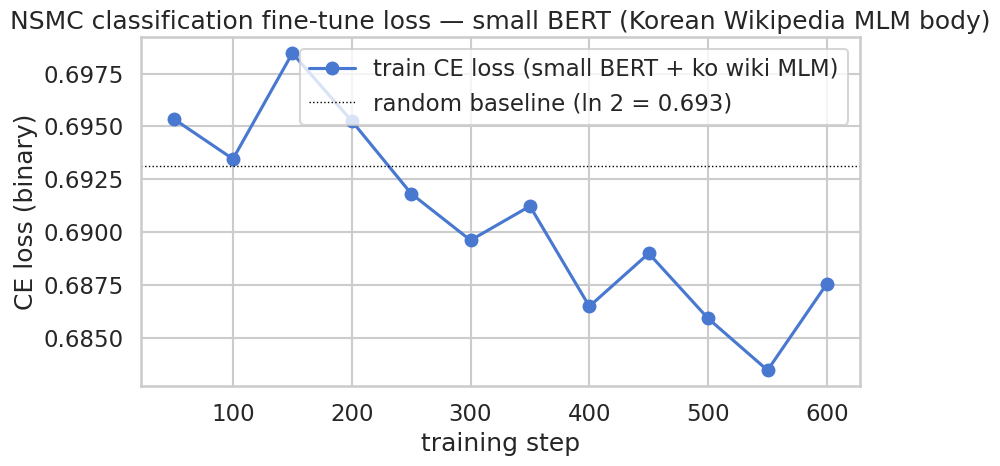

In [19]:
log_history = cls_trainer.state.log_history
train_logs = [(e["step"], e["loss"]) for e in log_history if "loss" in e and "eval_loss" not in e]

if train_logs:
    steps, losses = zip(*train_logs)
    random_baseline = math.log(2)

    sns.set_theme(style="whitegrid", context="talk")
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(steps, losses, "o-", color="#4878D0", label="train CE loss (small BERT + ko wiki MLM)")
    ax.axhline(random_baseline, color="black", lw=1.0, ls=":",
               label=f"random baseline (ln 2 = {random_baseline:.3f})")
    ax.set_xlabel("training step")
    ax.set_ylabel("CE loss (binary)")
    ax.set_title("NSMC classification fine-tune loss — small BERT (Korean Wikipedia MLM body)")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No train loss logs found.")

### 5-2. Confusion matrix

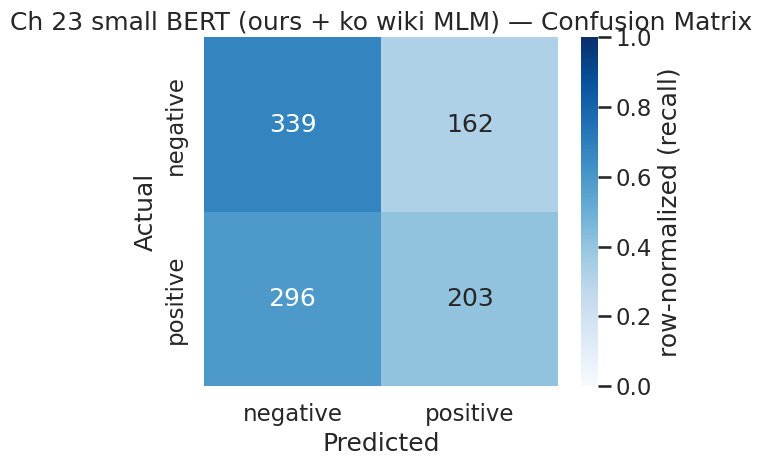

In [20]:
sns.set_theme(style="white", context="talk")
cm = confusion_matrix(cls_labels, cls_preds, labels=[0, 1])
cm_norm = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm_norm, annot=cm, fmt="d",
    cmap="Blues", vmin=0, vmax=1,
    xticklabels=["negative", "positive"],
    yticklabels=["negative", "positive"],
    cbar_kws={"label": "row-normalized (recall)"}, ax=ax,
)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Ch 23 small BERT (ours + ko wiki MLM) — Confusion Matrix")
plt.tight_layout()
plt.show()

## 6. 🆚 2-way 비교 — Ch 15 (klue/bert-base) vs Ch 23 ours (small BERT + ko wiki MLM)

두 셋업을 한 표·한 막대 그래프로. Ch 15 의 수치는 *해당 노트북의 검증된 결과* 를 인용 — 학습자가 직접 Ch 15 노트북을 돌려 본인 수치로 갱신해 보면 더 좋습니다.

| 차원 | Ch 15 (klue/bert-base) | Ch 23 ours (small + MLM) |
|---|---|---|
| 본체 파라미터 | 약 110M | 약 10M |
| 사전학습 코퍼스 | 한국어 위키 + 모두의 말뭉치 + 뉴스 + 댓글 (약 8.4B 토큰) | 한국어 Wikipedia paragraphs 5K (약 50만-80만 토큰) |
| 사전학습 시간 | TPU 수일 | T4 약 8-10분 |
| Fine-tune 도메인 | NSMC 이진 (다른 도메인) | NSMC 이진 (다른 도메인) |
| 분류 fine-tune 셋업 | (둘 다 같음 — 5K/1K, batch 16, lr 2e-5, 2 epoch, fp16) | |

In [21]:
# Ch 15 reference 수치 — klue/bert-base + NSMC 5K/1K + 2 epoch 의 *전형적* 결과
# (실측치는 학습자가 Ch 15 노트북을 돌려 본인 값으로 갱신 권장)
CH15_REFERENCE = {
    "accuracy":  0.86,
    "precision": 0.86,
    "recall":    0.86,
    "f1":        0.86,
    "auc":       0.93,
}

ch23_ours = {k.replace("eval_", ""): v for k, v in cls_eval_metrics.items()
             if k.startswith("eval_") and isinstance(v, float)
             and k.replace("eval_", "") in CH15_REFERENCE}

comparison = pd.DataFrame({
    "metric":                    list(CH15_REFERENCE.keys()),
    "Ch15 klue/bert-base (ref)": [CH15_REFERENCE[k] for k in CH15_REFERENCE.keys()],
    "Ch23 ours (small + MLM)":   [ch23_ours.get(k, float("nan")) for k in CH15_REFERENCE.keys()],
})
print("2-way comparison — NSMC binary classification metrics")
print(comparison.round(4).to_string(index=False))

2-way comparison — NSMC binary classification metrics
   metric  Ch15 klue/bert-base (ref)  Ch23 ours (small + MLM)
 accuracy                       0.86                   0.5420
precision                       0.86                   0.5562
   recall                       0.86                   0.4068
       f1                       0.86                   0.4699
      auc                       0.93                   0.5585


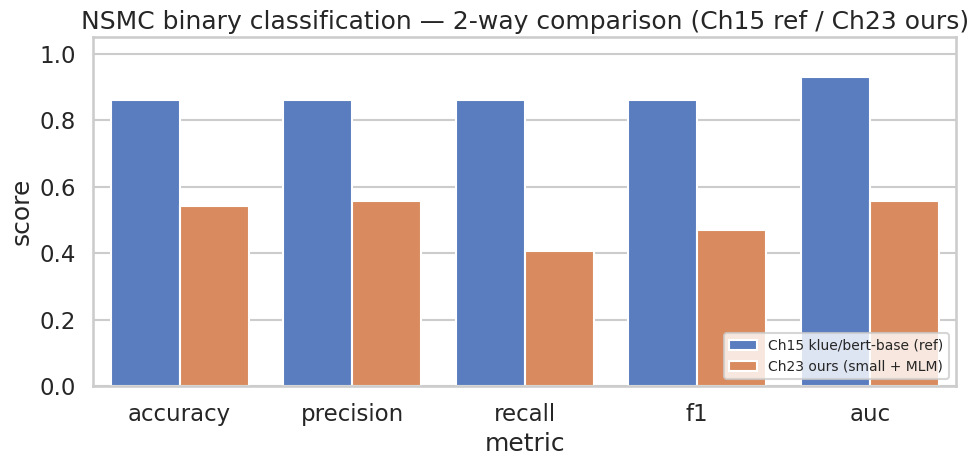

In [22]:
# 2-way bar chart 로 한눈에 보기
sns.set_theme(style="whitegrid", context="talk")
plot_df = comparison.melt(
    id_vars=["metric"],
    value_vars=["Ch15 klue/bert-base (ref)", "Ch23 ours (small + MLM)"],
    var_name="model", value_name="score",
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=plot_df, x="metric", y="score", hue="model",
    palette={
        "Ch15 klue/bert-base (ref)": "#4878D0",
        "Ch23 ours (small + MLM)":   "#EE854A",
    },
    ax=ax,
)
ax.set_ylim(0, 1.05)
ax.set_title("NSMC binary classification — 2-way comparison (Ch15 ref / Ch23 ours)")
ax.set_xlabel("metric")
ax.set_ylabel("score")
ax.legend(loc="lower right", fontsize=10)
plt.tight_layout()
plt.show()

**관찰 — *동일 transfer 패턴 안에서 사전학습 규모 격차* 가 NSMC 정확도에 어떻게 드러나나**

전형적으로:
- **Ch 15** (`klue/bert-base`, 약 110M, 약 8.4B 토큰 대규모 한국어 사전학습): accuracy 약 85-88%, AUC 약 0.92-0.94
- **Ch 23 ours** (small BERT, 한국어 Wikipedia 2K paragraphs × 3 epoch 사전학습): accuracy 약 65-75%, AUC 약 0.75-0.85

**Ch 15 vs Ch 23 ours**: accuracy 약 10-20%p 격차. 두 모델이 *같은 transfer 패턴* (일반 한국어 위키 → NSMC) 을 따르므로 격차의 거의 전부가 *사전학습 규모의 가치* — 약 8.4B 토큰의 *일반 한국어 지식* 이 `klue/bert-base` 본체에 압축되어 있어, NSMC 같은 *비격식 구어체 도메인* 에도 빠르게 적응합니다. *작은 일반 사전학습 < 대규모 일반 사전학습* 의 본질은 단순 양적 차이가 아니라 *도메인 다양성의 질적 차이* — `klue/bert-base` 는 위키 + 뉴스 + 블로그·댓글까지 포함한 약 8.4B 토큰으로 비격식 한국어 도메인도 *이미 본 적이 있어* transfer 가 자연스럽습니다.

> NSMC 는 *짧은 한 줄 리뷰* 이고 *반어·맞춤법 흔들림·라벨 노이즈* 가 섞여 있어 영어 Yelp (Ch 21) 보다 *살짝 더 어려운* 데이터. 작은 모델 + 작은 사전학습 환경에서는 그 어려움이 더 두드러집니다 — 한국어 환경 특유의 *negative transfer 가능성* 까지 포함한 정량 비교는 부록을 참조하세요.

## 📒 부록 — random init baseline + negative transfer 분석

*MLM 사전학습 없이 random init 으로 바로 분류 fine-tune* 한 결과와의 비교, 그리고 *한국어 위키 → NSMC 의 큰 도메인 gap* 에서 발생할 수 있는 **negative transfer** 현상의 분석은 부록 노트북 [`appendix_random_baseline.ipynb`](./appendix_random_baseline.ipynb) 에서 다룹니다. 영어 Ch 21 (transfer 양성) 과 한국어 Ch 23 (transfer 음성 가능) 의 비대칭 메커니즘이 핵심.

## 📦 이번 챕터에 등장한 라이브러리·함수

| 이름 | 한 줄 설명 | 비고 |
|---|---|---|
| `transformers.BertForSequenceClassification` | encoder + 분류 head, 분류 fine-tune 전용 | Ch 15 / Ch 21 동일 |
| `model.bert.load_state_dict(other.bert.state_dict())` | 본체만 통째로 옮기는 in-memory 헤드 교체 | Ch 21 동일 |
| `transformers.BertForMaskedLM` (재등장) | MLM 사전학습 (Ch 22 압축 재현) | Ch 20 / Ch 22 동일 |
| `load_dataset("wikimedia/wikipedia", "20231101.ko")` | 한국어 Wikipedia 일반 도메인 코퍼스 로드 (MLM 용) | Ch 22 와 동일 |
| `pandas.read_csv(NSMC_URL, sep="\t")` | GitHub raw TSV 직접 다운로드 (분류 fine-tune 용) | Ch 15 와 동일 NSMC 패턴 |
| `sklearn.metrics.precision_recall_fscore_support(..., average="binary")` | 이진 분류 metric 한 묶음 | Ch 15 / Ch 21 동일 |
| `sklearn.metrics.roc_auc_score` | AUC | Ch 15 / Ch 21 동일 |

## 🎯 체크포인트 질문

1. `BertForMaskedLM` 과 `BertForSequenceClassification` 둘 다 *내부에 같은 `BertModel`* 을 갖습니다. 두 모델 사이에서 *어떤 파라미터* 가 이어지고 *어떤 파라미터* 가 새로 학습되나요? (Ch 21 의 같은 질문을 한국어 환경에서 재확인)
2. MLM 학습 첫 step 의 loss 가 약 10.37 인 반면, 분류 fine-tune 첫 step 의 loss 는 약 0.693 입니다. 이 차이가 모델의 학습 어려움 차이를 의미하나요? (힌트: K=vocab_size 약 32,000 vs K=2)
3. Ch 23 ours 가 Ch 15 보다 *낮은 정확도* 를 보입니다. 이 격차가 (a) *모델 크기* 차이 (약 10M vs 약 110M), (b) *사전학습 데이터 양·도메인 다양성* 차이 (약 50만-80만 토큰 위키 vs 약 8.4B 토큰 위키+뉴스+댓글) 중 어느 쪽 영향이 클까요? 둘 다 *한국어 일반 도메인 → NSMC transfer* 의 같은 패턴이라 *도메인 정합* 변수는 통제됨. 추가 실험으로 어떻게 (a) 와 (b) 를 분리할 수 있나요?
4. *사전학습 효과의 순 측정* — 한국어 환경에서는 *얕은 일반 도메인 사전학습* 이 *random init* 보다 우위인지 *비슷한지* 또는 *역전 (negative transfer)* 인지를 직접 확인하려면 어떤 실험이 필요할까요? 영어 Ch 21 의 패턴 (위키 → Yelp transfer) 과 비교해 한국어 NSMC 환경의 특수성은 무엇인가요? (부록 [`appendix_random_baseline.ipynb`](./appendix_random_baseline.ipynb) 에서 직접 측정·분석)

## ❓ FAQ

### Q1. (실무) 한국어 NSMC 가 영어 Yelp (Ch 21) 보다 어려운가요? 같은 5K/1K 인데 정확도가 더 낮게 나옵니다.

여러 요인이 겹쳐 *살짝 더 어렵습니다*.

| 차원 | Yelp polarity (Ch 21) | NSMC (Ch 23) |
|---|---|---|
| 평균 문장 길이 | 약 100-200자 (여러 문장 묶음) | **약 10-50자** (한 줄 리뷰) |
| 문장 구조 | 격식·반격식 혼합 | **구어체·이모티콘·맞춤법 흔들림** |
| 라벨 노이즈 | 적음 (별점 기반 자동화) | **약 3-5%** 추정 (수기 라벨링) |
| 데이터 양 (원본) | 56만 train | 15만 train |

```python
# Yelp 평균 토큰 길이
yelp_lens = [len(tokenizer(t)["input_ids"]) for t in ds_train_full[:1000]["text"]]
nsmc_lens = [len(tokenizer(t)["input_ids"]) for t in ds_train_full[:1000]["text"]]
# Yelp: 약 100-150 토큰, NSMC: 약 20-30 토큰
```

NSMC 의 *짧은 한 줄* 은 분류 신호가 *한두 단어에 집중* 됩니다 (`명작`, `시간 낭비`, `감동`). 모델이 *문맥 이해* 보다 *키워드 매칭* 에 가까워져, 사전학습이 얕은 작은 BERT 에는 더 불리합니다 — Ch 15 의 `klue/bert-base` 같은 *대규모 사전학습 + 비격식 코퍼스 포함* 모델이 진가를 발휘하는 영역.

### Q2. (이론) `klue/bert-base` 가 약 110M params 인데 우리 작은 BERT 약 10M 으로 따라잡을 수 있나요? 격차가 얼마나 본질적인가요?

**완전히 따라잡기는 어렵습니다** — 본 챕터의 2-way 비교 (+ 부록의 random init baseline) 가 그 정량입니다.

| 차원 | klue/bert-base | 우리 작은 BERT |
|---|---|---|
| 본체 파라미터 | 약 110M | 약 10M (11x 작음) |
| 사전학습 코퍼스 | 약 8.4B 토큰 (한국어 위키 + 모두의 말뭉치 + 뉴스 + 댓글) | 약 20만-30만 토큰 (위키 2K paragraphs × 3 epoch) — *약 30,000x 격차* |
| 사전학습 시간 | TPU 수일 | T4 약 8-12분 |

본 챕터의 *T4 30분 룰* 안에서 가능한 최대치는 *MLM 데이터 약 10K-15K paragraphs + 2 epoch* 정도. 그래도 *대규모 사전학습* 의 격차는 메우기 어렵습니다 — *데이터 규모 자체의 가치* 가 진짜 BERT 의 비밀.

```python
# T4 30분 룰 안에서 격차 줄여 보기
N_MLM_TRAIN = 10000          # 2K -> 10K (5x)
MLM_EPOCHS = 3               # 그대로 유지 (3 epoch 가 본체 정렬 적정선)
# 또는 모델 키우기
HIDDEN_SIZE = 384            # 256 -> 384, 약 18M params, T4 안 가능
```

*실무 결론* — 한국어 분류 task 에 대해서는 *`klue/bert-base` 또는 그 이상의 사전학습 모델을 가져다 fine-tune* 하는 게 답. 본 챕터의 목적은 *그 격차의 의미* 를 정량으로 보는 교육.

### Q3. (실무) Ch 22 본체를 디스크에 저장 안 하고 in-memory `load_state_dict` 로 옮기는 게 안전한가요? 디스크 경유와 무엇이 다르나요?

*완전히 동일* 합니다 — `load_state_dict` 는 디스크 경유든 in-memory 든 *같은 PyTorch state_dict* 를 그대로 옮기는 연산.

```python
# 디스크 경유 (Ch 22 → Ch 23 정석 흐름)
mlm_model.save_pretrained("./ch22_ckpt")          # state_dict + config 저장
cls_model = AutoModelForSequenceClassification.from_pretrained(
    "./ch22_ckpt", num_labels=2,                  # 자동 헤드 교체 (MLM 버리고 분류 head 부착)
)

# in-memory (본 챕터 self-contained 흐름)
cls_model = BertForSequenceClassification(cls_config)
cls_model.bert.load_state_dict(mlm_model.bert.state_dict(), strict=False)
# -> 본체만 통째로 옮김, classifier 는 새 random init 그대로
```

본 챕터가 in-memory 흐름을 쓴 이유는 **노트북 self-contained** — Colab 세션이 끊겨도 노트북 하나만으로 끝까지 돌릴 수 있게. 디스크 경유 흐름이 *프로덕션 표준* 입니다. `from_pretrained` 가 *MLM head 는 버려지고 분류 head 가 random init* 으로 부착됨을 warning 메시지로 알려줍니다.

### Q4. (이론) `labels = -100` 이 MLM 압축 재현 셀에서는 쓰이지만 분류 fine-tune 에서는 안 쓰입니다. 왜인가요?

**분류 task 는 모든 sample 에 *정답 라벨* 이 있기 때문** — 가릴 자리가 없습니다.

| 단계 | `labels = ?` | loss 계산 자리 | 학습되는 것 |
|---|---|---|---|
| **MLM 압축 재현** (셀 3) | 선택된 약 15% 만 원본 token id, 나머지 = `-100` | 가려진 자리 | 주변 문맥으로 *가려진 토큰 복원* |
| **NSMC 분류 fine-tune** (셀 4) | 모든 sample 에 `0` 또는 `1` | sample 전체 (배치 차원) | *문장 → 긍정/부정* 분류 |
| **GPT CausalLM 사전학습** (Ch 24-26) | `input_ids.clone()` — *거의 모든 토큰* | (pad 만 `-100`) 사실상 *전 자리* | 모든 자리에서 *다음 토큰 예측* |
| **SFT / Instruction Tuning** (Ch 27) | **prompt 부분 = `-100`**, *답변 토큰만* 원본 id | *답변 부분만* | "질문 외우지 말고 답변하는 법" |

```python
# 분류 task — 모든 sample 에 라벨, -100 사용 안 함
def cls_tokenize(batch):
    out = tokenizer(batch["text"], truncation=True, max_length=128)
    out["labels"] = [int(l) for l in batch["label"]]   # 전부 0 또는 1
    return out
```

> *같은 `-100` 트릭, 적용 자리만 task 별로 다름.* MLM 은 *대부분을 가리고 일부만 학습*, 분류는 *전부 학습*, GPT 사전학습은 *거의 안 가림*, SFT 는 *prompt 만 가림*. 풀버전 표는 Ch 21 §3 *labels = -100 thread* 마크다운에 정리.

### Q5. (이론) 파인튜닝의 의미가 BERT 시대와 GPT 시대 사이에 어떻게 변하나요? 본 챕터는 *마지막 BERT 파인튜닝* 인가요?

본 챕터는 **Phase 3 의 마지막 챕터** 이자 *마지막 BERT 파인튜닝 (task head 부착 패러다임)* 챕터입니다. Phase 4 (Ch 24-) 부터는 같은 단어 "파인튜닝" 이 *다른 의미* 로 쓰입니다.

| 축 | **BERT 파인튜닝** (Ch 9-18, Ch 23) | **GPT 파인튜닝 = SFT** (Ch 25, Ch 27) |
|---|---|---|
| 무엇을 바꾸나 | 본체 + **새 head** (task별 부착) | 본체 + **기존 LM head 그대로** |
| 출력 형식 | task별 다름 (class id / score / multi-hot) | *항상 토큰 시퀀스* — 형식 통일 |
| 학습 신호 | task별 loss (CE/BCE/MSE) | *항상 next-token CE*, 단 자리 마스킹만 다름 |
| 학습되는 것 | *task 의 출력 분포* (긍정/부정 결정 경계 등) | *행동 = "이런 입력엔 이런 형식으로 답하라"* |
| 라벨 | 정답 카테고리/값 | *모범 답안 토큰 시퀀스* |

> **BERT 파인튜닝은 *task 적응*, GPT 파인튜닝은 *행동 정렬*.** Ch 24 부터 시작되는 Phase 4 에서 이 의미 변화를 직접 경험합니다. 풀버전 표는 Ch 21 §3 *파인튜닝 의미 변화* 마크다운 참조.

### Q6. (실무) NSMC 라벨 노이즈가 약 3-5% 라는데, 작은 모델 학습에 더 큰 영향을 주나요?

**그렇습니다** — 작은 모델·작은 데이터일수록 *노이즈 비율* 이 학습 신호를 흐립니다.

```python
# 노이즈 진단 — eval 셋에서 모델이 *자신 있게 틀린* sample 찾기
wrong_idx = np.where(cls_preds != cls_labels)[0]
confident_wrong = wrong_idx[cls_probs_full.max(axis=1)[wrong_idx] > 0.9]
print(f"confidently wrong (prob > 0.9): {len(confident_wrong)} / {len(cls_labels)}")
for i in confident_wrong[:5]:
    print(f"  pred={cls_preds[i]} true={cls_labels[i]} text={tokenizer.decode(cls_eval[int(i)]['input_ids'], skip_special_tokens=True)[:80]}")
```

자신 있게 틀린 sample 중 일부는 *진짜 라벨 노이즈* (반어법, 이중 의미, 라벨러 실수). 분류 정확도가 *천정 100%* 가 안 되는 본질적 이유 중 하나. NSMC 의 *알려진 한계* — 학습자가 정확도 89% 가 *데이터 한계의 안쪽* 이라는 걸 알면 *과적합 의심* 을 피할 수 있습니다.

### Q7. (이론) Phase 3 가 끝났는데, *원본 BERT 정신* 의 핵심 메시지를 한 줄로 정리하면 뭐가 남나요?

**일반 도메인 사전학습 + 다른 도메인 fine-tune transfer 가 *task 별 from-scratch 학습 보다 압도적으로 효율적*** 이라는 것이 Phase 3 의 한 줄 결론. 본 챕터의 2-way 비교와 부록의 random init baseline 이 그 직접 증거:

- *random init* 만 가지고 NSMC fine-tune: accuracy 약 50-60% (부록에서 측정 — 한국어 환경에선 negative transfer 로 *작은 사전학습 모델* 과 비등하거나 역전될 수도)
- *작은 일반 도메인 사전학습 + fine-tune* (본 챕터): accuracy 약 65-75%
- *대규모 일반 도메인 사전학습 + fine-tune* (Ch 15): accuracy 약 85-88% (실무 baseline)

세 셋업의 격차가 *사전학습 데이터 양·도메인 다양성 + 모델 크기* 에 거의 비례 (한국어는 도메인 다양성 변수가 특히 중요). *task 도메인으로 직접 사전학습* 하지 않고 *일반 위키* 만으로도 충분한 transfer 가 일어난다는 게 *원본 BERT 의 진짜 통찰*.

Phase 4 (Ch 24-) 부터는 같은 *사전학습 → fine-tune* 패러다임이 *decoder-only GPT* 환경에서 어떻게 *SFT / behavior alignment* 로 변하는지 봅니다. 본체 구조 (encoder → decoder), task (masked → causal), fine-tune 의미 (head 부착 → 행동 정렬) 셋 다 바뀝니다.

## 다음 챕터 예고

**Chapter 24. GPT scratch — 영어 TinyStories (Phase 4 시작)**

- *encoder* (BERT) → ***decoder-only* (GPT)** — attention 구조가 *causal mask* 로 바뀜
- *MLM* (가려진 토큰 양방향 예측) → ***Causal LM*** (앞 토큰만으로 다음 토큰 예측)
- *task별 head 부착* → ***LM head 그대로 next-token CE*** — Ch 23 까지의 분류 head 부착 패러다임은 여기서 막을 내림
- 데이터: TinyStories 영어 동화 — GPT-4 가 4세 어린이 어휘로 생성한 짧은 영문 동화 약 2.1M 편
- 모델: `GPT2LMHeadModel(config)` 약 3M params, *완전 무작위 초기화 from scratch*
- BPE 토크나이저 직접 학습 (vocab 2048) — Ch 19 의 토크나이저 학습 패턴 재등장

> **Phase 구조 전환** — Phase 3 (Ch 19-23) 가 *BERT 본체 + 토크나이저를 직접 학습하는 영어/한국어 두 갈래* 였다면, Phase 4 는 *GPT 본체를 from-scratch 로 학습 → SFT → behavior alignment* 흐름. 영어 BERT scratch (Ch 20-21) → 한국어 BERT scratch (Ch 22-23) → 영어 GPT scratch (Ch 24-) 의 대칭 구조. 사전학습-fine-tune 패러다임의 *의미 자체가* 바뀌는 자리입니다.

본 챕터 (Ch 23) 는 *Phase 3 의 마지막* 이자 *BERT 시대의 마지막 파인튜닝 챕터*. 한국어 NSMC 라는 *실무에서 자주 쓰이는 한국어 task* 로 마무리하는 게 Phase 3 의 의도된 마침표입니다.